
# Python Inference Tutorial - Single Model

This tutorial describes how to run an inference process using `InferPipeline` API (sync API), which is an alternative to the recommended Async API


**Requirements:**

* Run the notebook inside the Python virtual environment: ```source hailo_virtualenv/bin/activate```

When inside the ```virtualenv```, use the command ``hailo tutorial`` to open a Jupyter server that contains the tutorials.

In [2]:
import numpy as np
from multiprocessing import Process
from hailo_platform import (HEF, VDevice, HailoStreamInterface, InferVStreams, ConfigureParams,
    InputVStreamParams, OutputVStreamParams, InputVStreams, OutputVStreams, FormatType)

# The target can be used as a context manager ("with" statement) to ensure it's released on time.
# Here it's avoided for the sake of simplicity
target = VDevice()

# Loading compiled HEFs to device:
# model_name = 'yolo11n'
# hef_path = '../hefs/{}.hef'.format(model_name) 
hef_path = '/home/trap-fish/uav-human-detection/models/yolo11n_visdrone.hef'
hef = HEF(hef_path)
    
# Configure network groups
configure_params = ConfigureParams.create_from_hef(hef=hef, interface=HailoStreamInterface.PCIe)
network_groups = target.configure(hef, configure_params)
network_group = network_groups[0]
network_group_params = network_group.create_params()

# Create input and output virtual streams params
input_vstreams_params = InputVStreamParams.make(network_group, format_type=FormatType.FLOAT32)
output_vstreams_params = OutputVStreamParams.make(network_group, format_type=FormatType.FLOAT32)

# Define dataset params
input_vstream_info = hef.get_input_vstream_infos()[0]
output_vstream_info = hef.get_output_vstream_infos()[0]
image_height, image_width, channels = input_vstream_info.shape
num_of_images = 10
low, high = 2, 20

# Generate random dataset
dataset = np.random.randint(low, high, (num_of_images, image_height, image_width, channels)).astype(np.float32)

#### Running hardware inference
Infer the model and then display the output shape:

In [3]:
# Infer 
with InferVStreams(network_group, input_vstreams_params, output_vstreams_params) as infer_pipeline:
    input_data = {input_vstream_info.name: dataset}
    with network_group.activate(network_group_params):
        infer_results = infer_pipeline.infer(input_data)
        print(f"Stream output shape is {infer_results[output_vstream_info.name][0][:]}")

infer_results

Stream output shape is [array([], shape=(0, 5), dtype=float64), array([], shape=(0, 5), dtype=float64)]


{'yolo11n_visdrone/yolov8_nms_postprocess': [[array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)],
  [array([], shape=(0, 5), dtype=float64),
   array([], shape=(0, 5), dtype=float64)]]}

## Streaming inference

This section shows how to run streaming inference using multiple processes in Python.

Note: This flow is not supported on Windows.

We will not use infer. Instead we will use a send and receive model.
The send function and the receive function will run in different processes.

Define the send and receive functions:

In [4]:
def send(configured_network, num_frames):
    configured_network.wait_for_activation(1000)
    vstreams_params = InputVStreamParams.make(configured_network)
    with InputVStreams(configured_network, vstreams_params) as vstreams:
        vstream_to_buffer = {vstream: np.ndarray([1] + list(vstream.shape), dtype=vstream.dtype) for vstream in vstreams}
        for _ in range(num_frames):
            for vstream, buff in vstream_to_buffer.items():
                vstream.send(buff)

def recv(configured_network, vstreams_params, num_frames):
    configured_network.wait_for_activation(1000)
    with OutputVStreams(configured_network, vstreams_params) as vstreams:
        for _ in range(num_frames):
            for vstream in vstreams:
                data = vstream.recv()

def recv_all(configured_network, num_frames):
    vstreams_params_groups = OutputVStreamParams.make_groups(configured_network)
    recv_procs = []
    for vstreams_params in vstreams_params_groups:
        proc = Process(target=recv, args=(configured_network, vstreams_params, num_frames))
        proc.start()
        recv_procs.append(proc)
    for proc in recv_procs:
        proc.join()

Define the amount of frames to stream, define the processes, create the target and run processes:


In [5]:
# Define the amount of frames to stream
num_of_frames = 1000
model_name = "yolo11n_visdrone"

send_process = Process(target=send, args=(network_group, num_of_frames))
recv_process = Process(target=recv_all, args=(network_group, num_of_frames))
recv_process.start()
send_process.start()
print('Starting streaming (hef=\'{}\', num_of_frames={})'.format(model_name, num_of_frames))
with network_group.activate(network_group_params):
    send_process.join()
    recv_process.join()
print('Done')

target.release()

Starting streaming (hef='yolo11n_visdrone', num_of_frames=1000)
Done


## HEF Model Processing

In [6]:
target.release()

In [2]:
import os

# OpenCV for computer vision tasks
import cv2

# NumPy for numerical operations
import numpy as np

# PIL (Python Imaging Library) for image processing
from PIL import Image, ImageDraw, ImageFont

# Import Hailo Runtime dependencies
from hailo_platform import (
    HEF,
    ConfigureParams,
    FormatType,
    HailoSchedulingAlgorithm,
    HailoStreamInterface,
    InferVStreams,
    InputVStreamParams,
    OutputVStreamParams,
    VDevice
)

# Import Picamera2
# from picamera2 import Picamera2, Preview

In [3]:
import json
import time
import torchvision as tv

# preprocessing - just wrapper for resize and to format into an array
def preproc(image, output_height=640, output_width=640):
    preprocess = tv.transforms.Compose([
        tv.transforms.Resize((output_height, output_width)),
    ])
    
    data = np.array(preprocess(image))
    
    return data

rootdir = '/home/trap-fish/uav-human-detection/hailo-ai/'
# annotations_file = os.path.join(rootdir, 'shared_with_docker/visdrone/annotations_VisDroneHumans_val.json')
# images_path = '/home/trap-fish/uav-human-detection/datasets/filtered/visdrone_humans/val/images' #os.path.join(rootdir, 'shared_with_docker/visdrone/VisDrone2019-DET-val/images')

annotations_file = '/home/trap-fish/uav-human-detection/hailo-ai/shared_with_docker/visdrone/annotations_VisDroneHumans_val2.json'
images_path = '/home/trap-fish/uav-human-detection/datasets/filtered/visdrone_humans/val/images'
with open(annotations_file, 'r') as f:
    val_gt = json.load(f)
    f.close()
    
images = val_gt['images']
image_list = [(x['file_name'],x['id']) for x in images] 

print(f"frame count: {len(image_list)}")

dataset_sz = len(image_list)
val_dataset = np.zeros((dataset_sz, 640, 640, 3))
for idx, imagename_id in enumerate(image_list):
    imgname, imgid = imagename_id
    image_file = os.path.join(images_path, imgname)
    img = Image.open(image_file).convert('RGB')
    img_preproc = preproc(img)
    val_dataset[idx, :, :, :] = img_preproc

frame count: 532


In [7]:
# Load the compiled HEF to Hailo device
root_path = '/home/trap-fish/uav-human-detection/hailo-ai/shared_with_docker/visdrone/models/best/hef/'
model = 'yolov5np2-ghost_visdrone_singlecls_quant_model.hef'
hef_path = os.path.join(root_path, model)
hef = HEF(str(hef_path))

# Set VDevice (Virtual Device) params to disable the HailoRT service feature
params = VDevice.create_params()
params.scheduling_algorithm = HailoSchedulingAlgorithm.NONE

# Create a Hailo virtual device with the specified parameters
target = VDevice(params=params)

# Get the "network groups" (connectivity groups, aka. "different networks") information from the .hef
# Configure the device with the HEF and PCIe interface
configure_params = ConfigureParams.create_from_hef(hef=hef, interface=HailoStreamInterface.PCIe)
network_groups = target.configure(hef, configure_params)

# Select the first network group (there's only one in this case)
network_group = network_groups[0]
network_group_params = network_group.create_params()

# Create input and output virtual streams params
# These specify the format of the input and output data (in this case, 32-bit float)
input_vstreams_params = InputVStreamParams.make(network_group, format_type=FormatType.FLOAT32)
output_vstreams_params = OutputVStreamParams.make(network_group, format_type=FormatType.FLOAT32)

# Get information about the input and output virtual streams
input_vstream_info = hef.get_input_vstream_infos()[0]
output_vstream_info = hef.get_output_vstream_infos()[0]

In [8]:

sample_frame_path = "/home/trap-fish/uav-human-detection/hailo-ai/exported_from_docker/val/images/0000001_03999_d_0000007.jpg"
# Capture a frame
frame = Image.open(sample_frame_path)

input_img_np = preproc(frame)

# Resize and pad the sample image to the desired input size, retrieving transformation data.
#input_img_np, transform_data = resize_and_pad(frame, input_vstream_info.shape[::-1][1:], True)

# Convert the input image to NumPy format for the model
input_tensor_np = np.array(input_img_np, dtype=np.float32)[None]
input_tensor_np = np.ascontiguousarray(input_tensor_np)

# Run inference
input_data = {input_vstream_info.name: input_tensor_np}
with InferVStreams(network_group, input_vstreams_params, output_vstreams_params) as infer_pipeline:
    with network_group.activate(network_group_params):
        infer_results = infer_pipeline.infer(input_data)

# Transpose and extract the first element of the quantized results
outputs = infer_results[output_vstream_info.name]#.transpose(0, 1, 3, 2)[0]


In [9]:
def run_inference(vstream_params, input_data):
    network_group, input_vstreams_params, output_vstreams_params = vstream_params
    #input_data = {input_vstream_info.name: input_tensor}
    with InferVStreams(network_group, input_vstreams_params, output_vstreams_params) as infer_pipeline:
        with network_group.activate(network_group_params):
            infer_results = infer_pipeline.infer(input_data)
    return infer_results

In [10]:
# create an np array for the validation dataset
vstream_config = (network_group, input_vstreams_params, output_vstreams_params)
outs = []
start_time = time.perf_counter()
for idx, imagename_id in enumerate(image_list):
    img_arr = val_dataset[idx, :, :, :]
    
    # # Convert the input image to NumPy format for the model
    input_tensor_np = np.array(img_arr, dtype=np.float32)[None]
    input_tensor_np = np.ascontiguousarray(input_tensor_np)
    
    input_data = {input_vstream_info.name: input_tensor_np}

    outs.append(run_inference(vstream_config, input_data))

# Calculate and display FPS
end_time = time.perf_counter()
processing_time = end_time - start_time
fps = 1 / processing_time


In [11]:
print(f"Inference time {processing_time}\nFPS: {len(image_list) * fps}")

Inference time 11.700172809999913
FPS: 45.46941388295648


In [12]:
 

def remove_zero_padding(output, imgid):
    # remove zero-padding and transpose detections into single array
    combined = np.empty((7, 0)) # 1 classid, xywh, score
    for i in range(output.shape[1]):
        valid_mask = np.any(output[0,i,:,:] != 0, axis=(0))  # Check if any non-zero values exist in each column
        last_valid_indices = np.argmax(~valid_mask, axis=0) # First occurrence of zero padding
        if last_valid_indices==0:
            last_valid_indices=-1
        dets = output[0, i, :, :last_valid_indices]
        class_col = np.full_like(dets[0,None], i) # add the classID into the array
        imgid_col = np.full_like(dets[0,None], imgid)
        dets = np.vstack((dets, class_col, imgid_col))
        combined = np.concatenate((combined, dets), axis=1)

    dets = combined.T
    return dets


def swap_columns(detections):
    swapped = detections.copy()
    swapped[:, [0, 1,2,3]] = swapped[:, [1, 0, 3, 2]]
    return swapped


def ltxy2xywh(xywh):
    coco_format = np.array(xywh)
    coco_format[:,0] = xywh[:,0] # x
    coco_format[:,1] = xywh[:,1] # y
    coco_format[:,2] = xywh[:,2] - xywh[:,0] # x2 - x1
    coco_format[:,3] = xywh[:,3] - xywh[:,1] # y2 - y1

    return coco_format

def rescale_bbox(detections, w, h):
    w_arr = np.full_like(detections[:,0], w)
    h_arr = np.full_like(detections[:,0], h)
    scaled = np.zeros_like(detections)
    
    scaled[:,0] = detections[:,0] * w_arr
    scaled[:,1] = detections[:,1] * h_arr
    scaled[:,2] = detections[:,2] * w_arr
    scaled[:,3] = detections[:,3] * h_arr
    
    scaled[:, 4:] = detections[:, 4:]
    
    return scaled

def add_metadata_to_dict(data, data_dict):
    idx, imgid, lb_scale, lb_pad_top, lb_pad_left = data
    metadata = {
                "image_id" : imgid,
                "lbox_scale": lb_scale,
                "lbox_pad_top": lb_pad_top, 
                "lbox_pad_left": lb_pad_left
    }


    data_dict[idx]["rescale_data"] = metadata
    


def get_image_metadata(images_dict, img_id):
    for img in images_dict:
        if img['id'] == img_id:
            orig_w, orig_h = img['width'], img['height']
            name = img["file_name"]
            lb_scale = img["rescale_data"]["lbox_scale"]
            lb_pad_top = img["rescale_data"]["lbox_pad_top"]
            lb_pad_left = img["rescale_data"]["lbox_pad_left"]

    return orig_w, orig_h, name, lb_scale, lb_pad_top, lb_pad_left

def batch_detections_to_json(detections):
    class_remap = {0: 1, 1: 2}
    res = []
    annId = 1
    for el in detections:
        x,y,w,h,conf,classid,imgid = el
        imgid = int(imgid)
        res.append({"image_id": imgid, "category_id": class_remap[classid], "bbox": [x,y,w,h], "score": conf, "id": annId, "segmentation": []}) 
        annId +=1
    return res

def stack_image_detections(image_detections, image_id):
    stacked = np.empty((0,7))
    for idx, dets in enumerate(image_detections):
        axis_sz = dets.shape[0]
        dets_with_cls = np.full((axis_sz, 7), idx, dtype="float32")
        dets_with_cls[:, :-2] = dets
        dets_with_cls[:, -1] = image_id
        stacked = np.vstack((stacked, dets_with_cls))
    return stacked

In [13]:
for key in outs[0]:
    key = key
key


'yolov5np2_ghost_visdrone/yolov5_nms_postprocess'

In [14]:
outs[0]

{'yolov5np2_ghost_visdrone/yolov5_nms_postprocess': [[array([[3.35214317e-01, 6.19149029e-01, 3.66011143e-01, 6.31193995e-01,
           6.23529434e-01],
          [1.65220112e-01, 5.47679067e-01, 1.92672059e-01, 5.60311139e-01,
           6.00000024e-01],
          [3.31900239e-01, 6.18656874e-01, 3.69374305e-01, 6.37715697e-01,
           5.29411793e-01],
          [3.34145039e-01, 6.21411800e-01, 3.64041239e-01, 6.34911776e-01,
           5.05882382e-01],
          [1.66605636e-01, 5.49718857e-01, 1.87659085e-01, 5.58369398e-01,
           4.94117677e-01],
          [3.39242101e-01, 6.22199655e-01, 3.60267669e-01, 6.37702346e-01,
           4.15686309e-01],
          [2.74643898e-01, 6.67804241e-01, 3.08836520e-01, 6.79107606e-01,
           3.60784322e-01],
          [2.14272872e-01, 5.52733302e-01, 2.42050648e-01, 5.61041236e-01,
           2.62745112e-01],
          [1.68457761e-01, 5.51817834e-01, 1.87351063e-01, 5.57373405e-01,
           2.47058734e-01],
          [1.17719620e

In [22]:
import json
import numpy as np

# Load your annotations file (for image metadata)
annotations_file = '/home/trap-fish/uav-human-detection/hailo-ai/shared_with_docker/visdrone/annotations_VisDroneHumans_val2.json'
with open(annotations_file, 'r') as f:
    annotations_data = json.load(f)

image_infos = annotations_data['images']

# Replace this with your actual Hailo output
hailo_output = outs

# Convert to COCO results format
coco_results = []
annotation_id = 1

for img_idx, img_info in enumerate(image_infos):
    if img_idx >= len(hailo_output):
        break

    img_id = img_info['id']
    width, height = img_info['width'], img_info['height']
    bboxes = hailo_output[img_idx]['yolov5np2_ghost_visdrone/yolov5_nms_postprocess'][0][0]

    for box in bboxes:
        x1, y1, x2, y2, conf = box
        x = float(x1 * width)
        y = float(y1 * height)
        w = float((x2 - x1) * width)
        h = float((y2 - y1) * height)

        coco_results.append({
            'image_id': img_id,
            'category_id': 1,
            'bbox': [x, y, w, h],
            'score': float(conf),
            'id': annotation_id,
            'segmentation': []
        })
        annotation_id += 1

# Save the results
with open("hailo_results_coco_results.json", "w") as f:
    json.dump(coco_results, f, indent=2)



In [13]:
all_image_dets = np.empty((0,7))
for idx, item in enumerate(outs):
    detections = item[key]
    single_img_det = stack_image_detections(detections[0], idx+1)
    all_image_dets = np.vstack((all_image_dets, single_img_det))
    
xyxy_dets = swap_columns(all_image_dets)
dets_scaled = rescale_bbox(xyxy_dets, 1920, 1080)
xywh = ltxy2xywh(dets_scaled)
anns_json = batch_detections_to_json(xywh)


In [14]:
modelname = str.split(os.path.basename(hef_path), ".")[0]
outfilename = modelname + ".json"
with open(outfilename, "w") as f:
    json.dump(anns_json, f)

In [15]:
target.release()

In [16]:
with open(outfilename, "r") as f:
    annotations = json.load(f)

annotations[0:3]

[{'image_id': 1,
  'category_id': 1,
  'bbox': [1188.7661361694336,
   362.0314621925354,
   23.12633514404297,
   33.26057195663452],
  'score': 0.6235294342041016,
  'id': 1,
  'segmentation': []},
 {'image_id': 1,
  'category_id': 1,
  'bbox': [1051.5438079833984,
   178.43772053718567,
   24.253578186035156,
   29.64810311794281],
  'score': 0.6000000238418579,
  'id': 2,
  'segmentation': []},
 {'image_id': 1,
  'category_id': 1,
  'bbox': [1187.8211975097656,
   358.4522581100464,
   36.59294128417969,
   40.471991300582886],
  'score': 0.529411792755127,
  'id': 3,
  'segmentation': []}]

In [17]:
def rescale_bboxes(annotations, image_info):
    # Create a mapping of image_id to its correct dimensions
    image_dims = {img['id']: (img['width'], img['height']) for img in image_info}
    
    # Original incorrect dimensions
    incorrect_w, incorrect_h = 1920, 1080
    
    for ann in annotations:
        img_id = ann['image_id']
        if img_id in image_dims:
            correct_w, correct_h = image_dims[img_id]
            
            # Scale bbox from incorrect to correct dimensions
            x, y, w, h = ann['bbox']
            x = (x / incorrect_w) * correct_w
            y = (y / incorrect_h) * correct_h
            w = (w / incorrect_w) * correct_w
            h = (h / incorrect_h) * correct_h
            
            ann['bbox'] = [x, y, w, h]
    
    return annotations
corrected = rescale_bboxes(annotations, images)
outputfile = modelname+".json"
with open(outputfile, "w") as f:
    json.dump(corrected, f)
print(f"file saved to {outputfile}")

file saved to yolov5np2-ghost_visdrone_singlecls_quant_model.json


In [16]:
saved_file = f"/home/trap-fish/uav-human-detection/hailo-ai/shared_with_docker/visdrone/results/{outputfile.split('_')[0]}_hef_model.json"
!cp {outputfile} {saved_file}
print(f"copied {outputfile} to {saved_file}")

copied yolov5np2_visdrone_singlecls_quant_model.json to /home/trap-fish/uav-human-detection/hailo-ai/shared_with_docker/visdrone/results/yolov5np2_hef_model.json


In [23]:

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import pylab

import json
import os

pylab.rcParams['figure.figsize'] = (10.0, 8.0)

annType = ['segm','bbox','keypoints']
annType = annType[1]      #specify type here
prefix = 'person_keypoints' if annType=='keypoints' else 'instances'
print('Running demo for *%s* results.'%(annType))

#initialize COCO ground truth api
rootdir = '/home/trap-fish/uav-human-detection/hailo-ai/'
# annFile = os.path.join(rootdir, 'shared_with_docker/visdrone/annotations_VisDroneHumans_val.json')
annFile = '/home/trap-fish/uav-human-detection/datasets/filtered/visdrone_humans/val/export_annotations_VisDroneHumans_val.json'
cocoGt=COCO(annFile)

#initialize COCO detections api
# resFile= outputfile
resFile = 'hailo_results_coco_results.json'
cocoDt=cocoGt.loadRes(resFile)

imgIds=sorted(cocoGt.getImgIds())
imgIds = imgIds[0:]
catIDs = [1,2] # 81 for all IDs
useCats = 0
maxDets = [1, 10, 100]

# running evaluation
cocoEval = COCOeval(cocoGt,cocoDt,annType)
cocoEval.params.imgIds  = imgIds
cocoEval.params.catIds = catIDs
cocoEval.params.maxDets = maxDets
cocoEval.params.useCats = useCats
cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()


Running demo for *bbox* results.
loading annotations into memory...
Done (t=0.35s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.24s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=28.92s).
Accumulating evaluation results...
DONE (t=0.62s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU

In [19]:
import faster_coco_eval

# Replace pycocotools with faster_coco_eval
faster_coco_eval.init_as_pycocotools()

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

anno = COCO(str(annFile))  # init annotations api
# resFile = "/home/trap-fish/uav-human-detection/hailo-ai/shared_with_docker/visdrone/results/yolov5sp2_openvino_model.json"
pred = anno.loadRes(str(resFile))  # init predictions api (must pass string, not Path)

val = COCOeval(anno, pred, "bbox")
val.params.imgIds  = imgIds
val.params.maxDets = maxDets
val.params.catIds = catIDs
val.params.useCats = useCats


val.evaluate()
val.accumulate()
val.summarize()


Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.77s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.034
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.127
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.065
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.008
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.040
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.117
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.116
 Average Recall     (AR) @[

In [43]:
val.stats

array([0.09914643, 0.33189653, 0.02473177, 0.08720167, 0.20759471,
       0.0642972 , 0.01345121, 0.08048536, 0.19450927, 0.18319464,
       0.28759591, 0.075     ])

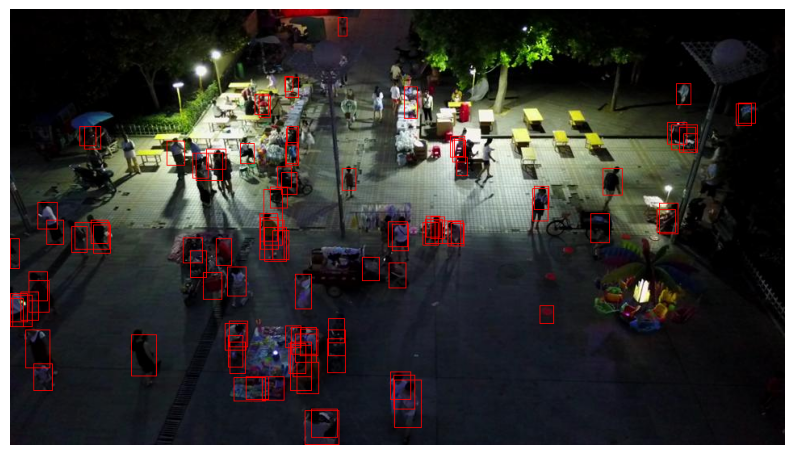

In [29]:
import cv2
import matplotlib.pyplot as plt
import json
def plot_annotations(root_path, annotations, image_id, categories):
    for image in images:
        if image["id"] == image_id:
            filename = image["file_name"]
    image_path = os.path.join(root_path, filename)
    
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print("Warning: Image not loaded")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Filter annotations for the specific image_id
    image_annotations = [ann for ann in annotations if ann['image_id'] == image_id]
    
    # Draw bounding boxes
    for ann in image_annotations:
        if ann["category_id"] in categories:
            x, y, w, h = map(int, ann['bbox'])
            cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 1)
    
    # Display the image
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# Example usage
predfile = outputfile
with open(predfile, 'r') as f:
    preds = json.load(f)
    f.close()

openvino_preds = '/home/trap-fish/uav-human-detection/hailo-ai/shared_with_docker/visdrone/results/yolov5n_openvino_model.json'
with open(openvino_preds, 'r') as f:
    ov_preds = json.load(f)
    f.close()

imagedir = '/home/trap-fish/uav-human-detection/datasets/filtered/visdrone_humans/val/images'

# plot_annotations(imagedir, ov_preds, 4, (1,2))
plot_annotations(imagedir, preds, 32, (1,2))

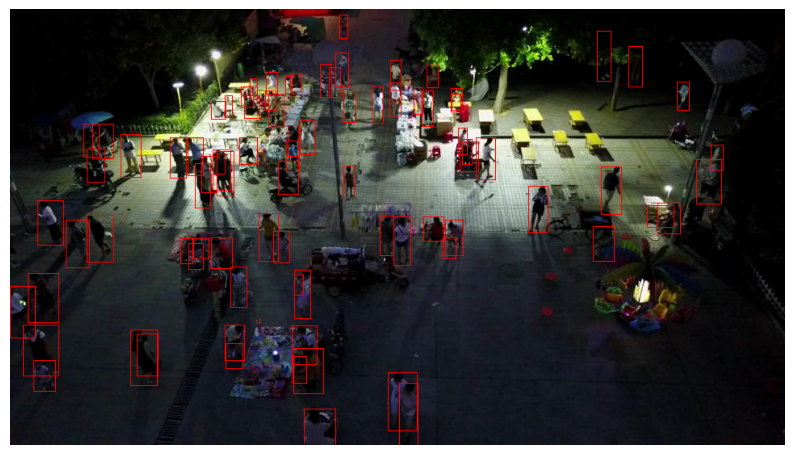

In [30]:
rootdir = '/home/trap-fish/uav-human-detection/datasets/filtered/visdrone_humans/val/images/'
gt_filepath = '/home/trap-fish/uav-human-detection/datasets/filtered/visdrone_humans/val/export_annotations_VisDroneHumans_val.json'
with open(gt_filepath, 'r') as f:
    gt_anns = json.load(f)
    f.close()

gt_anns = gt_anns["annotations"]
plot_annotations(rootdir, gt_anns, 32, (1,2))

In [ ]:

# Process the model output to get object proposals
proposals = process_outputs(outputs, input_vstream_info.shape[:-1], bbox_conf_thresh)

# Apply non-max suppression to filter overlapping proposals
proposal_indices = nms_sorted_boxes(calc_iou(proposals[:, :-2]), iou_thresh)
proposals = proposals[proposal_indices]

# Extract bounding boxes, labels, and probabilities from proposals
bbox_list = [adjust_bbox(bbox, transform_data) for bbox in proposals[:,:4]]
label_list = [class_names[int(idx)] for idx in proposals[:,4]]
probs_list = proposals[:,5]

# Initialize track IDs for detected objects
track_ids = [-1]*len(bbox_list)

# Convert bounding boxes to top-left bottom-right (tlbr) format
tlbr_boxes = np.array(bbox_list).reshape(-1,4).copy()
tlbr_boxes[:, 2:4] += tlbr_boxes[:, :2]

# Update tracker with detections
tracks = tracker.update(
    output_results=np.concatenate([tlbr_boxes, probs_list[:, np.newaxis]], axis=1),
    img_info=frame.shape[::-1][1:],
    img_size=frame.shape[::-1][1:])

if len(tlbr_boxes) > 0 and len(tracks) > 0:
    # Match detections with tracks
    track_ids = match_detections_with_tracks(tlbr_boxes=tlbr_boxes, track_ids=track_ids, tracks=tracks)

    # Filter object detections based on tracking results
    bbox_list, label_list, probs_list, track_ids = zip(*[(bbox, label, prob, track_id) 
                                                        for bbox, label, prob, track_id 
                                                        in zip(bbox_list, label_list, probs_list, track_ids) if track_id != -1])
    
    if len(bbox_list) > 0:
        # Annotate the current frame with bounding boxes and tracking IDs
        annotated_img = draw_bboxes_pil(
            image=Image.fromarray(frame), 
            boxes=bbox_list, 
            labels=[f"{track_id}-{label}" for track_id, label in zip(track_ids, label_list)],
            probs=probs_list,
            colors=[int_colors[class_names.index(i)] for i in label_list],  
            font=font_file,
        )
        annotated_frame = cv2.resize(np.array(annotated_img), (preview_width, preview_height))
else:
    # If no detections, use the original frame
    annotated_frame = cv2.resize(frame, (preview_width, preview_height))

# Calculate and display FPS
end_time = time.perf_counter()
processing_time = end_time - start_time
fps = 1 / processing_time

fps_text = f"FPS: {fps:.2f}"
cv2.putText(annotated_frame, fps_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Display the annotated frame
cv2.imshow(window_title, annotated_frame)

# Check for 'q' key press to exit the loop
if cv2.waitKey(1) & 0xFF == ord('q'):
    break
finally:
    # Stop the camera and close the preview window
    cv2.destroyAllWindows()
    picam2.close()

In [2]:
from picamera2 import Picamera2, Preview
import cv2
import time
picam2 = Picamera2()

print("Available sensor modes:")
for i, mode in enumerate(picam2.sensor_modes):
    print(f"Mode {i}: {mode['size']}x{mode['fps']}fps")

# Choose a mode (let's say we want the second mode, index 1)
chosen_mode = picam2.sensor_modes[0]

# Create a configuration using the chosen mode
config = picam2.create_preview_configuration(
    main={
        "size": chosen_mode["size"],
        "format": "RGB888"
    },
    controls={
        "FrameRate": chosen_mode["fps"]
    },
    sensor={
        "output_size": chosen_mode["size"],
        "bit_depth": chosen_mode["bit_depth"]
    }
)


camera_config = picam2.create_preview_configuration()
picam2.configure(camera_config)
picam2.start()
frame = picam2.capture_array()

[1:45:53.792128742] [17254]  INFO Camera camera_manager.cpp:327 libcamera v0.4.0+53-29156679
[1:45:53.799420166] [17287]  INFO RPI pisp.cpp:720 libpisp version v1.1.0 e7974a156008 27-01-2025 (21:50:51)
[1:45:53.809454300] [17287]  INFO RPI pisp.cpp:1179 Registered camera /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a to CFE device /dev/media0 and ISP device /dev/media1 using PiSP variant BCM2712_C0
[1:45:53.813372642] [17254]  INFO Camera camera.cpp:1202 configuring streams: (0) 640x480-XBGR8888 (1) 1536x864-BGGR_PISP_COMP1
[1:45:53.813475309] [17287]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a - Selected sensor format: 1536x864-SBGGR10_1X10 - Selected CFE format: 1536x864-PC1B
[1:45:53.817619726] [17254]  INFO Camera camera.cpp:1202 configuring streams: (0) 640x480-XBGR8888 (1) 2304x1296-BGGR_PISP_COMP1
[1:45:53.817748985] [17287]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a - Selected sensor format: 2304x12

Available sensor modes:
Mode 0: (1536, 864)x120.13fps
Mode 1: (2304, 1296)x56.03fps
Mode 2: (4608, 2592)x14.35fps


In [17]:

camera_config = picam2.create_preview_configuration()
picam2.configure(camera_config)
picam2.start()
frame = picam2.capture_array()

[0:24:55.291844256] [8179]  INFO Camera camera.cpp:1202 configuring streams: (0) 640x480-XBGR8888 (1) 1536x864-BGGR_PISP_COMP1
[0:24:55.292039089] [13849]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a - Selected sensor format: 1536x864-SBGGR10_1X10 - Selected CFE format: 1536x864-PC1B


### Testing inference on camera stream

In [29]:
from picamera2 import Picamera2, Preview
import cv2
import time


picam2 = Picamera2()

print("Available sensor modes:")
for i, mode in enumerate(picam2.sensor_modes):
    print(f"Mode {i}: {mode['size']}x{mode['fps']}fps")

# Choose a mode (let's say we want the second mode, index 1)
chosen_mode = picam2.sensor_modes[0]

# Create a configuration using the chosen mode
config = picam2.create_preview_configuration(
    main={
        "size": chosen_mode["size"],
        "format": "RGB888"
    },
    controls={
        "FrameRate": chosen_mode["fps"]
    },
    sensor={
        "output_size": chosen_mode["size"],
        "bit_depth": chosen_mode["bit_depth"]
    }
)


# camera_config = picam2.create_preview_configuration()
# picam2.configure(camera_config)
# picam2.start()
# frame = picam2.capture_array()

# # create an np array for the validation dataset
# vstream_config = (network_group, input_vstreams_params, output_vstreams_params)
# outs = []
# start_time = time.perf_counter()
# for idx, imagename_id in enumerate(image_list):
#     img_arr = val_dataset[idx, :, :, :]
    
#     # # Convert the input image to NumPy format for the model
#     input_tensor_np = np.array(img_arr, dtype=np.float32)[None]
#     input_tensor_np = np.ascontiguousarray(input_tensor_np)
    
#     input_data = {input_vstream_info.name: input_tensor_np}

#     outs.append(run_inference(vstream_config, input_data))

# # Calculate and display FPS
# end_time = time.perf_counter()
# processing_time = end_time - start_time
# fps = 1 / processing_time

camera_config = picam2.create_preview_configuration()
picam2.configure(camera_config)
picam2.start()
frame = picam2.capture_array()
picam2.close()

Available sensor modes:
Mode 0: (1536, 864)x120.13fps
Mode 1: (2304, 1296)x56.03fps
Mode 2: (4608, 2592)x14.35fps


[1:52:55.455046977] [17254]  INFO Camera camera.cpp:1202 configuring streams: (0) 640x480-XBGR8888 (1) 1536x864-BGGR_PISP_COMP1
[1:52:55.455215385] [17304]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a - Selected sensor format: 1536x864-SBGGR10_1X10 - Selected CFE format: 1536x864-PC1B
[1:52:55.460807489] [17254]  INFO Camera camera.cpp:1202 configuring streams: (0) 640x480-XBGR8888 (1) 2304x1296-BGGR_PISP_COMP1
[1:52:55.460965564] [17304]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a - Selected sensor format: 2304x1296-SBGGR10_1X10 - Selected CFE format: 2304x1296-PC1B
[1:52:55.467535929] [17254]  INFO Camera camera.cpp:1202 configuring streams: (0) 640x480-XBGR8888 (1) 4608x2592-BGGR_PISP_COMP1
[1:52:55.467697467] [17304]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a - Selected sensor format: 4608x2592-SBGGR10_1X10 - Selected CFE format: 4608x2592-PC1B
[1:52:55.478769250] [1725

In [30]:
frame.shape

(480, 640, 4)

In [68]:
from picamera2 import Picamera2, Preview
import cv2
import time

vstream_config = (network_group, input_vstreams_params, output_vstreams_params)

picam2 = Picamera2()

# Choose a mode (let's say we want the second mode, index 1)
chosen_mode = picam2.sensor_modes[0]

# Create a configuration using the chosen mode
config = picam2.create_preview_configuration(
    main={
        "size": chosen_mode["size"],
        "format": "RGB888"
    },
    controls={
        "FrameRate": chosen_mode["fps"]
    },
    sensor={
        "output_size": chosen_mode["size"],
        "bit_depth": chosen_mode["bit_depth"]
    }
)



camera_config = picam2.create_preview_configuration()
picam2.configure(camera_config)
picam2.start()


print("Capturing video...")
i=0
start_time = time.perf_counter()
frame_count = 300
outs = []
while i < frame_count:
    frame = picam2.capture_array()
    i+=1
    example_resz, _ = resize_and_pad(frame[:,:,:-1], (640, 640))
    input_img_np = example_resz
    
    # Resize and pad the sample image to the desired input size, retrieving transformation data.
    #input_img_np, transform_data = resize_and_pad(frame, input_vstream_info.shape[::-1][1:], True)
    
    # Convert the input image to NumPy format for the model
    input_tensor_np = np.array(input_img_np, dtype=np.float32)[None]
    input_tensor_np = np.ascontiguousarray(input_tensor_np)
    
    # Run inference
    input_data = {input_vstream_info.name: input_tensor_np}
    with InferVStreams(network_group, input_vstreams_params, output_vstreams_params) as infer_pipeline:
        with network_group.activate(network_group_params):
            infer_results = infer_pipeline.infer(input_data)
    
    outs.append(infer_results)
    
        
end_time = time.perf_counter()
picam2.close()

# Calculate and display FPS
processing_time = end_time - start_time
fps = 1 / processing_time

[2:06:58.805064293] [17254]  INFO Camera camera.cpp:1202 configuring streams: (0) 640x480-XBGR8888 (1) 1536x864-BGGR_PISP_COMP1
[2:06:58.805234256] [17304]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a - Selected sensor format: 1536x864-SBGGR10_1X10 - Selected CFE format: 1536x864-PC1B
[2:06:58.811193645] [17254]  INFO Camera camera.cpp:1202 configuring streams: (0) 640x480-XBGR8888 (1) 2304x1296-BGGR_PISP_COMP1
[2:06:58.811497979] [17304]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a - Selected sensor format: 2304x1296-SBGGR10_1X10 - Selected CFE format: 2304x1296-PC1B
[2:06:58.818269871] [17254]  INFO Camera camera.cpp:1202 configuring streams: (0) 640x480-XBGR8888 (1) 4608x2592-BGGR_PISP_COMP1
[2:06:58.818435612] [17304]  INFO RPI pisp.cpp:1484 Sensor: /base/axi/pcie@1000120000/rp1/i2c@80000/imx708@1a - Selected sensor format: 4608x2592-SBGGR10_1X10 - Selected CFE format: 4608x2592-PC1B
[2:06:58.829810795] [1725

Capturing video...


In [69]:
picam2.close()
frame_count / processing_time

38.69115322846563

In [70]:
len(outs)

300

In [5]:
from typing import Tuple, Optional, NamedTuple
class ImageTransformData(NamedTuple):
    """
    A data class that stores transformation information applied to an image.

    Attributes:
        offset (Tuple[int, int]): The (x, y) offset where the resized image was pasted.
        scale (float): The scaling factor applied to the original image.
    """
    offset: Tuple[int, int]
    scale: float
    
def resize_and_pad(
    image: np.ndarray,
    target_sz: Tuple[int, int],
    return_transform_data: bool = False,
    fill_color: Tuple[int, int, int] = (255, 255, 255)
) -> Tuple[np.ndarray, Optional[ImageTransformData]]:
    """
    Resize an image while maintaining its aspect ratio and pad it to fit the target size.

    Args:
        image (np.ndarray): The original image as a numpy array.
        target_sz (Tuple[int, int]): The desired size (width, height) for the output image.
        return_transform_data (bool, optional): If True, returns transformation data (offset and scale).
        fill_color (Tuple[int, int, int], optional): The color to use for padding (default is white).

    Returns:
        Tuple[np.ndarray, Optional[ImageTransformData]]: The resized and padded image,
        and optionally the transformation data.
    """
    target_width, target_height = target_sz
    orig_height, orig_width = image.shape[:2]
    
    aspect_ratio = orig_width / orig_height
    target_aspect_ratio = target_width / target_height

    if aspect_ratio > target_aspect_ratio:
        new_width = target_width
        new_height = int(new_width / aspect_ratio)
        scale = target_width / orig_width
    else:
        new_height = target_height
        new_width = int(new_height * aspect_ratio)
        scale = target_height / orig_height

    resized_image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_NEAREST)

    paste_x = (target_width - new_width) // 2
    paste_y = (target_height - new_height) // 2

    padded_image = np.full((target_height, target_width, 3), fill_color, dtype=np.uint8)
    padded_image[paste_y:paste_y+new_height, paste_x:paste_x+new_width] = resized_image

    if return_transform_data:
        transform_data = ImageTransformData(offset=(paste_x, paste_y), scale=scale)
        return padded_image, transform_data
    else:
        return padded_image, None

In [43]:
from PIL import Image

picam2.start()
print("Capturing video...")
start_time = time.perf_counter()
frame = picam2.capture_array()
example_resz, _ = resize_and_pad(frame[:,:,:-1], (640, 640))
print(f"frame shape: {example_resz.shape}")

input_img_np = example_resz

# Resize and pad the sample image to the desired input size, retrieving transformation data.
#input_img_np, transform_data = resize_and_pad(frame, input_vstream_info.shape[::-1][1:], True)

# Convert the input image to NumPy format for the model
input_tensor_np = np.array(input_img_np, dtype=np.float32)[None]
input_tensor_np = np.ascontiguousarray(input_tensor_np)

# Run inference
input_data = {input_vstream_info.name: input_tensor_np}
with InferVStreams(network_group, input_vstreams_params, output_vstreams_params) as infer_pipeline:
    with network_group.activate(network_group_params):
        infer_results = infer_pipeline.infer(input_data)

# Transpose and extract the first element of the quantized results
outputs = infer_results[output_vstream_info.name]#.transpose(0, 1, 3, 2)[0]

Capturing video...
frame shape: (640, 640, 3)


In [44]:
outputs

[[array([], shape=(0, 5), dtype=float64),
  array([], shape=(0, 5), dtype=float64)]]

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Saved object size data to object_sizes.csv


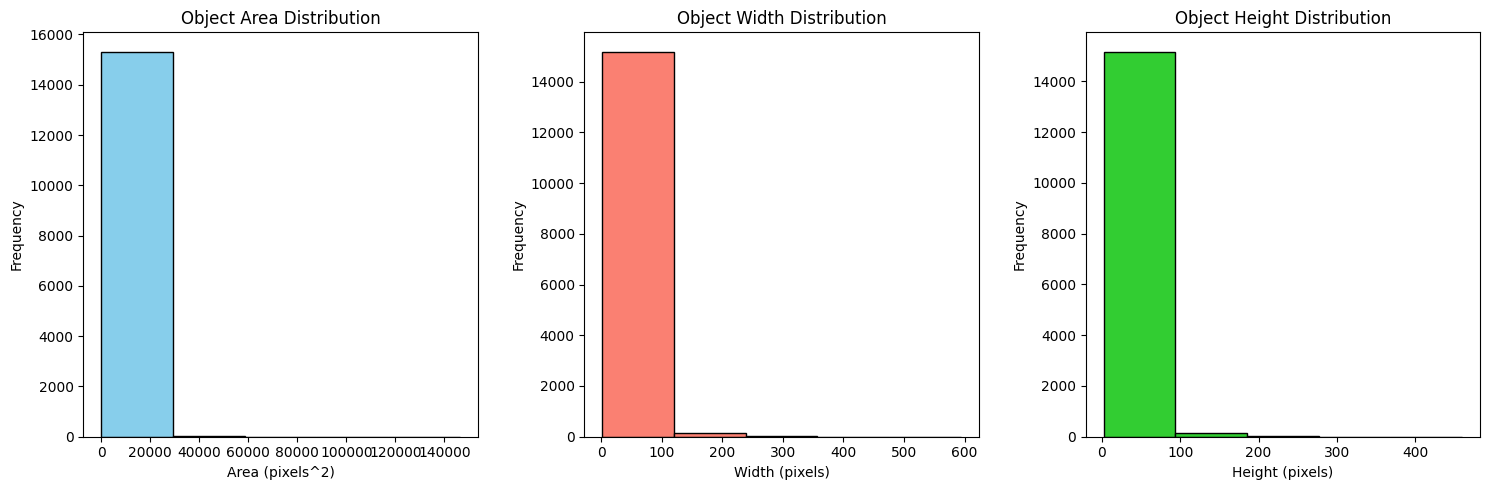

Saved histogram as object_size_distribution.png


In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# === Path to your annotation file ===
coco_annotation_path = "/home/trap-fish/uav-human-detection/hailo-ai/shared_with_docker/visdrone/annotations_VisDroneHumans_val.json"


# Load the dataset
coco = COCO(coco_annotation_path)

# Get all annotations
annotations = coco.loadAnns(coco.getAnnIds())

# Extract width, height, and compute area
object_data = []

for ann in annotations:
    x, y, width, height = ann['bbox']
    area = width * height
    object_data.append({'width': width, 'height': height, 'area': area})

# Convert to DataFrame
df = pd.DataFrame(object_data)

# === Save CSV ===
df.to_csv("object_sizes.csv", index=False)
print("Saved object size data to object_sizes.csv")

# === Plotting ===
plt.figure(figsize=(15, 5))

# Area histogram
plt.subplot(1, 3, 1)
plt.hist(df['area'], bins=5, color='skyblue', edgecolor='black')
plt.title("Object Area Distribution")
plt.xlabel("Area (pixels^2)")
plt.ylabel("Frequency")

# Width histogram
plt.subplot(1, 3, 2)
plt.hist(df['width'], bins=5, color='salmon', edgecolor='black')
plt.title("Object Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

# Height histogram
plt.subplot(1, 3, 3)
plt.hist(df['height'], bins=5, color='limegreen', edgecolor='black')
plt.title("Object Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("object_size_distribution.png")
plt.show()

print("Saved histogram as object_size_distribution.png")
